In [1]:
import sys, os
import numpy as np
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import matplotlib.pyplot as plt
import xarray as xr

sys.path.insert(0, os.path.abspath('../model'))
sys.path.insert(0, os.path.abspath('../parameter_scan'))

from cariaco_ssm_setup import (
    model, model_setup, model_setup_stability, generate_size_classes,
    compute_K_s, compute_mu_max_maranon, compute_I_max,
    compute_fish_kernel_vdl_joint,
)
from resize_cariaco_setup import make_resized_setup, build_cariaco_regenerators
from spectrum_plot import plot_normalised_biomass_spectrum
from xso.parscans import StabilityAnalysisHook

In [11]:
loaded_setup = xr.open_dataset('../parameter_scan/best_cell_stability.nc')

n_P_new, n_Z_new = 12, 12
P_new = generate_size_classes(n_P_new, esd_min=0.5, esd_max=200)
Z_new = generate_size_classes(n_Z_new, esd_min=5,   esd_max=2000)

regen = build_cariaco_regenerators(
    compute_K_s, compute_mu_max_maranon,
    compute_I_max, compute_fish_kernel_vdl_joint,
)

new_setup_ivp = make_resized_setup(
    loaded_setup=loaded_setup, model=model,
    phyto_esd=P_new, zoo_esd=Z_new,
    regenerators=regen,
    solver='solve_ivp', time=np.arange(0, 5000, 1),
)

new_setup_stab = make_resized_setup(
    loaded_setup=loaded_setup, model=model,
    phyto_esd=P_new, zoo_esd=Z_new,
    regenerators=regen,
    solver='stability', time=[0, 1],
)

[INFO] Initial state dimension: 26
[INFO] Initial state: [1.83352691e+00 1.60011862e-01 6.05213700e-05 1.23187868e-01
 3.83362792e-26 8.46492394e-02 3.62347518e-02 3.96785868e-02
 1.43968986e-13 3.14112594e-54 4.29308458e-51 1.81313137e-14
 7.29897716e-02 8.53953281e-03 1.13686586e-08 2.33246174e-02
 4.81848718e-07 7.70831889e-02 1.46757021e-02 6.37322799e-02
 3.57692353e-06 4.60046055e-02 2.63438222e-02 1.98738377e-04
 1.30556627e-19 5.13293174e-01]
[INFO] Steady state found with residual norm: 2.82e-14
  Steady state: [ 1.83153926e+00  1.60014863e-01  1.66495106e-13  1.23199600e-01
 -3.67498651e-35  8.43462784e-02  3.67934893e-02  3.94917915e-02
 -5.71596600e-21  1.39010866e-63  8.14331218e-60  7.08666229e-23
  7.37316341e-02  8.53993542e-03  6.85716069e-16  2.33278508e-02
 -2.05021337e-15  7.70578848e-02  1.46454702e-02  6.36644862e-02
  2.42745576e-15  4.57155644e-02  2.69044037e-02  1.46747786e-12
  5.51099590e-27  5.13329535e-01]
[INFO] Computing Jacobian numerically...
[INFO] Su

In [3]:
# IVP spin-up
with model:
    out_ivp = new_setup_ivp.xsimlab.run()

# Tail-mean of IVP becomes initial condition for stability solver
AVG_WINDOW = 1000
n_avg = float(out_ivp.Nutrient__value
              .isel(time=slice(-AVG_WINDOW, None)).mean('time').values)
p_avg = (out_ivp.Phytoplankton__biomass
         .isel(time=slice(-AVG_WINDOW, None)).mean('time').values)
z_avg = (out_ivp.Zooplankton__biomass
         .isel(time=slice(-AVG_WINDOW, None)).mean('time').values)
d_avg = float(out_ivp.Detritus__value
              .isel(time=slice(-AVG_WINDOW, None)).mean('time').values)

ss_overrides = {
    'Nutrient__value_init':        n_avg,
    'Phytoplankton__biomass_init': p_avg,
    'Zooplankton__biomass_init':   z_avg,
    'Detritus__value_init':        d_avg,
}

# IMPORTANT: use new_setup_stab (not cariaco's model_setup_stability),
# otherwise the array shapes won't match the resized grid.
with model:
    out_ss = (new_setup_stab
              .xsimlab.update_vars(input_vars=ss_overrides)
              .xsimlab.run())

ss_phyto_new = out_ss.Phytoplankton__biomass.isel(time=-1).values
ss_zoo_new   = out_ss.Zooplankton__biomass.isel(time=-1).values
ss_nut_new   = float(out_ss.Nutrient__value.isel(time=-1).values)

[INFO] Initial state dimension: 26
[INFO] Initial state: [1.83703758e+00 1.60050771e-01 9.82665343e-05 1.23174765e-01
 1.59510805e-26 8.52039082e-02 3.52665883e-02 4.00111397e-02
 1.55233993e-09 2.00325349e-51 5.93683042e-52 2.60891202e-15
 7.20159325e-02 8.53868608e-03 3.45981605e-09 2.33223804e-02
 5.11069311e-06 7.70788243e-02 1.48070489e-02 6.37664242e-02
 1.63382988e-06 4.65232175e-02 2.54240750e-02 5.17465455e-04
 4.40063343e-19 5.13290050e-01]
[INFO] Steady state found with residual norm: 4.23e-13
  Steady state: [ 1.83153926e+00  1.60014863e-01 -1.21843917e-12  1.23199600e-01
  9.41988993e-35  8.43462784e-02  3.67934893e-02  3.94917914e-02
  8.82320576e-16 -3.83131178e-60 -4.92882409e-60 -7.91719535e-23
  7.37316342e-02  8.53993542e-03 -1.35435323e-16  2.33278508e-02
  2.85364980e-13  7.70578848e-02  1.46454702e-02  6.36644861e-02
 -2.03949719e-15  4.57155643e-02  2.69044038e-02 -1.21540549e-11
  7.79854092e-27  5.13329535e-01]
[INFO] Computing Jacobian numerically...
[INFO] Su

In [2]:
# IVP spin-up
with model:
    out_ivp = model_setup.xsimlab.run()

# Tail-mean of IVP becomes initial condition for stability solver
AVG_WINDOW = 1000
n_avg = float(out_ivp.Nutrient__value
              .isel(time=slice(-AVG_WINDOW, None)).mean('time').values)
p_avg = (out_ivp.Phytoplankton__biomass
         .isel(time=slice(-AVG_WINDOW, None)).mean('time').values)
z_avg = (out_ivp.Zooplankton__biomass
         .isel(time=slice(-AVG_WINDOW, None)).mean('time').values)
d_avg = float(out_ivp.Detritus__value
              .isel(time=slice(-AVG_WINDOW, None)).mean('time').values)

ss_overrides = {
    'Nutrient__value_init':        n_avg,
    'Phytoplankton__biomass_init': p_avg,
    'Zooplankton__biomass_init':   z_avg,
    'Detritus__value_init':        d_avg,
}

# IMPORTANT: use new_setup_stab (not cariaco's model_setup_stability),
# otherwise the array shapes won't match the resized grid.
with model:
    out_ss = (model_setup_stability
              .xsimlab.update_vars(input_vars=ss_overrides)
              .xsimlab.run())

ss_phyto_new = out_ss.Phytoplankton__biomass.isel(time=-1).values
ss_zoo_new   = out_ss.Zooplankton__biomass.isel(time=-1).values
ss_nut_new   = float(out_ss.Nutrient__value.isel(time=-1).values)

[INFO] Initial state dimension: 26
[INFO] Initial state: [7.97990288e-02 4.07677676e-01 1.95674106e-22 2.11736051e-01
 1.03911707e-01 3.25293998e-01 1.34220876e-22 1.01295644e-41
 5.56622202e-50 2.53701112e-49 1.51240774e-44 8.62126505e-39
 9.83071949e-34 8.28090893e-02 1.41602890e-01 9.80927523e-14
 1.58651042e-01 3.43387249e-03 2.39904237e-41 1.75300975e-64
 2.23928839e-70 2.38035511e-73 1.73804302e-74 1.10376907e-75
 7.83001393e-81 4.58201316e-01]
[INFO] Steady state found with residual norm: 1.55e-13
  Steady state: [ 7.96298272e-02  4.06697473e-01  1.86871430e-31  2.13360606e-01
  9.75542737e-02  3.32784677e-01  1.17304475e-31  1.75502978e-51
  1.85592874e-60  2.94779522e-60  9.56109866e-56  3.22779552e-50
  2.18660190e-45  8.28034935e-02  1.41664143e-01  1.70318220e-22
  1.58164729e-01  3.19976035e-03  7.75065836e-51 -1.22440815e-78
  2.87835624e-81 -2.89132778e-84 -2.53852198e-85 -1.37163751e-86
 -9.00694587e-92  4.58459884e-01]
[INFO] Computing Jacobian numerically...
[INFO] Su

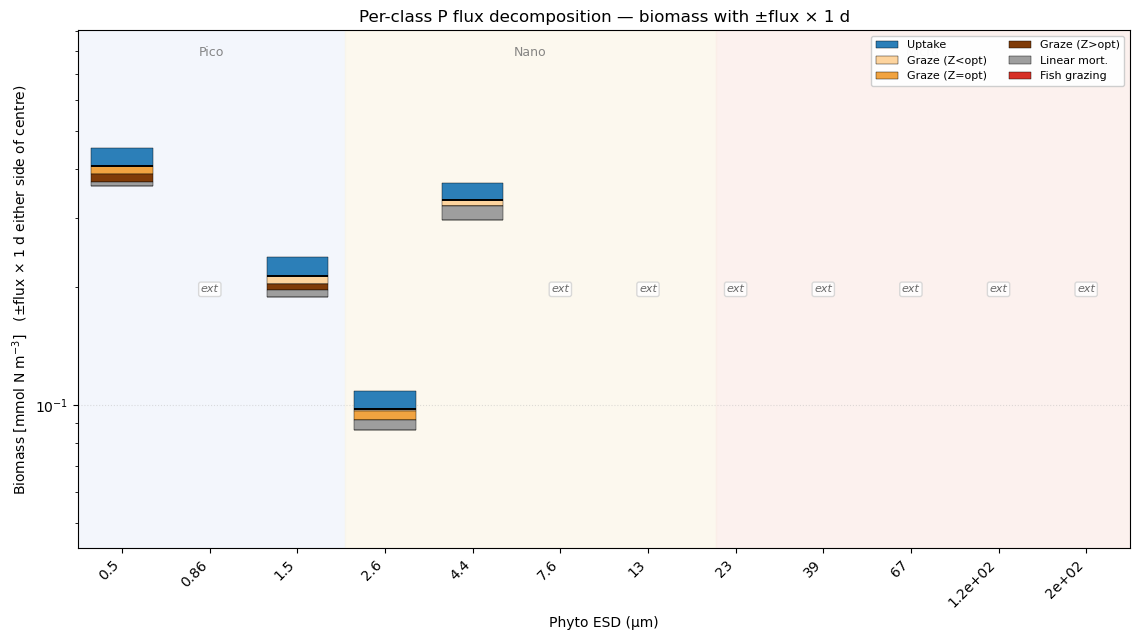

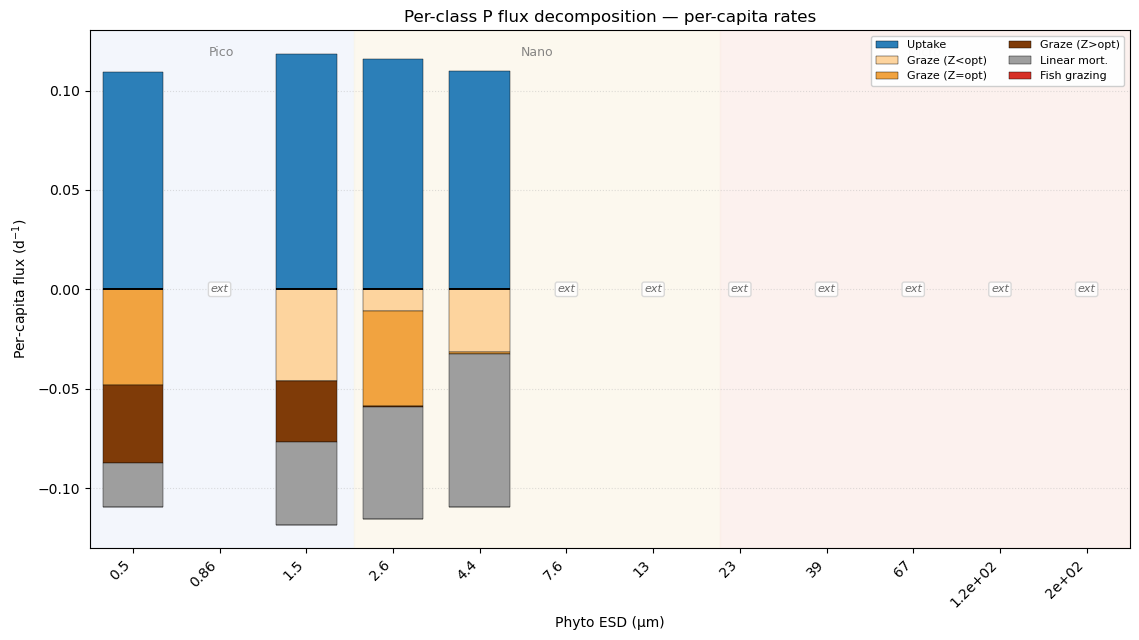

In [3]:
from flux_plot import plot_phyto_flux_decomposition

# Biomass-centred view (size spectrum visible as the bar centre line; log-y).
fig, ax = plt.subplots(figsize=(11.5, 6.5))
plot_phyto_flux_decomposition(out_ss, mode='biomass', dt=1.0, ax=ax)
plt.tight_layout()
plt.show()

# Per-capita rate view (centred at zero; linear-y; matches R*-style framing).
fig, ax = plt.subplots(figsize=(11.5, 6.5))
plot_phyto_flux_decomposition(out_ss, mode='per_capita', ax=ax)
plt.tight_layout()
plt.show()

In [4]:
from flux_plot import summarize_phyto_fluxes
data = summarize_phyto_fluxes(out_ss)

Per-class phytoplankton flux decomposition — steady state
  Run params: F_N=2.67, d_e=50, K_sZ=3, GGE=0.25
  Units: mmol N m^-3 d^-1; (xx%) = fraction of total loss for that class

 i      ESD        P_ss  |     Uptake  ||          Gr<opt           Gr=opt           Gr>opt            Mort.             Fish  |      Σloss         Net
-------------------------------------------------------------------------------------------------------------------------------------------------------
 0      0.5   4.067e-01  | +4.450e-02  || 0.00e+00 (  0%)  1.95e-02 ( 44%)  1.59e-02 ( 36%)  9.04e-03 ( 20%)  2.56e-05 (  0%)  |  4.450e-02   +8.82e-15
 1    0.862   <extinct>
 2     1.49   2.134e-01  | +2.527e-02  || 9.87e-03 ( 39%)  1.16e-23 (  0%)  6.56e-03 ( 26%)  8.82e-03 ( 35%)  1.37e-05 (  0%)  |  2.527e-02   +7.41e-15
 3     2.56   9.755e-02  | +1.129e-02  || 1.06e-03 (  9%)  4.67e-03 ( 41%)  5.28e-05 (  0%)  5.50e-03 ( 49%)  6.39e-06 (  0%)  |  1.129e-02   +7.75e-14
 4     4.42   3.328e-01  | +3.646e-

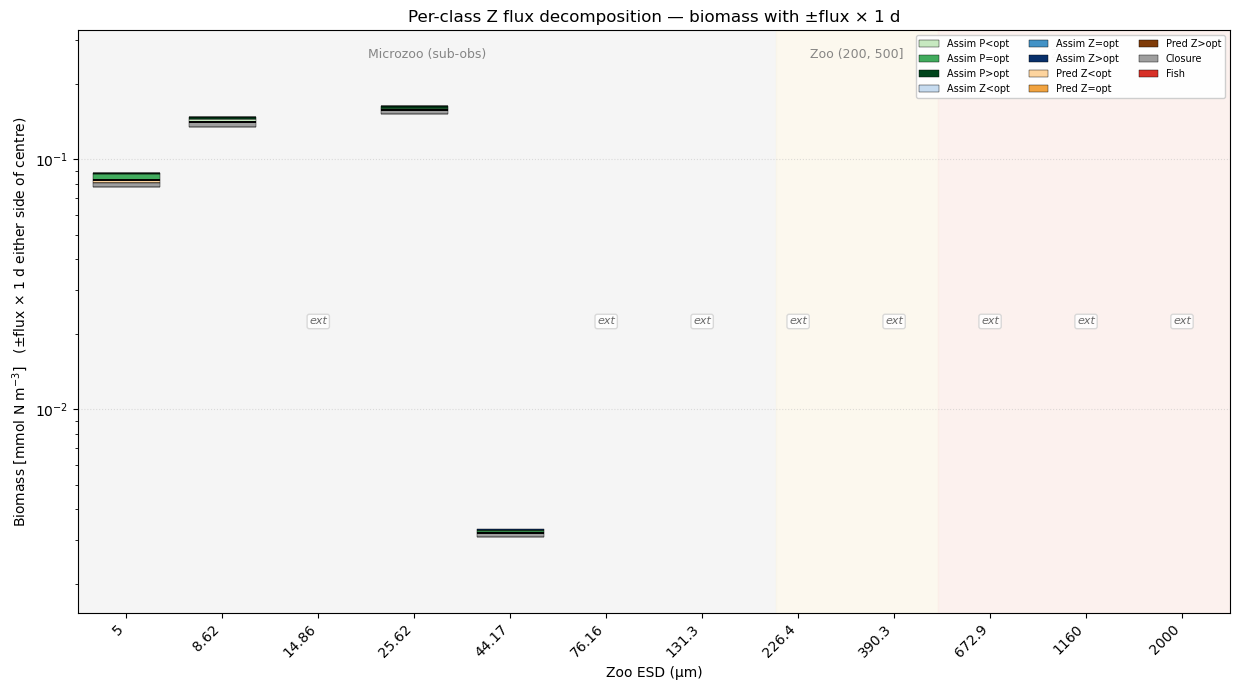

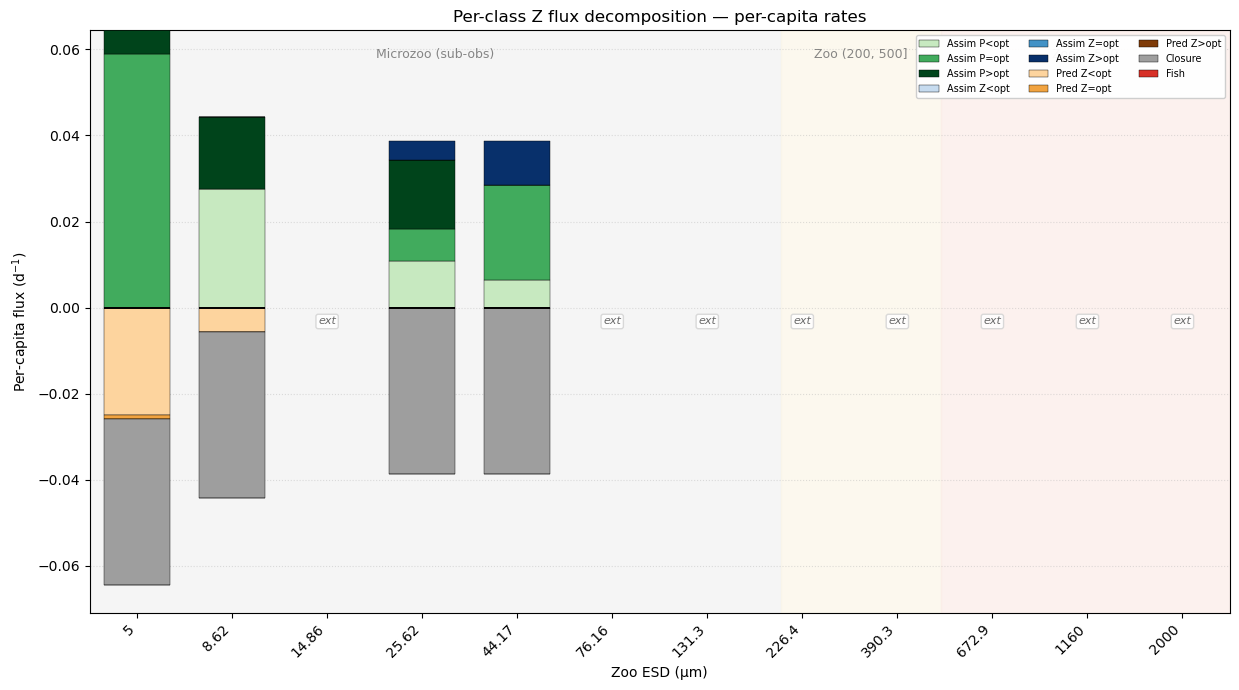

Per-class zooplankton flux decomposition — steady state
  Run params: gge=0.25, K_sZ=3, m_Z=0.1, fish_rate=0.005
  Units: mmol N m^-3 d^-1; (xx%) = fraction of total source/loss for that class

SOURCE SIDE — gge x ingestion, by prey type and prey-size relative to optimal
 j       ESD        Z_ss  |          P<opt           P=opt           P>opt  ||           Z<opt           Z=opt           Z>opt  |      Σ src     P:Z share
----------------------------------------------------------------------------------------------------------------------------------------------------------
 0         5   8.280e-02  | 0.00e+00 (  0%)  4.88e-03 ( 92%)  4.51e-04 (  8%)  ||  0.00e+00 (  0%)  0.00e+00 (  0%)  8.28e-09 (  0%)  |  5.335e-03   100% /   0%
 1      8.62   1.417e-01  | 3.89e-03 ( 62%)  0.00e+00 (  0%)  2.37e-03 ( 38%)  ||  0.00e+00 (  0%)  0.00e+00 (  0%)  1.17e-05 (  0%)  |  6.273e-03   100% /   0%
 2     14.86   <extinct>
 3     25.62   1.582e-01  | 1.72e-03 ( 28%)  1.17e-03 ( 19%)  2.55e-03 

In [5]:
from flux_plot import plot_zoo_flux_decomposition, summarize_zoo_fluxes

fig, ax = plt.subplots(figsize=(12.5, 7.0))
plot_zoo_flux_decomposition(out_ss, mode='biomass', dt=1.0, ax=ax)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(12.5, 7.0))
plot_zoo_flux_decomposition(out_ss, mode='per_capita', ax=ax)
plt.tight_layout(); plt.show()

zdata = summarize_zoo_fluxes(out_ss)

# PLOT THEORETICAL FLUX SPECTRUM

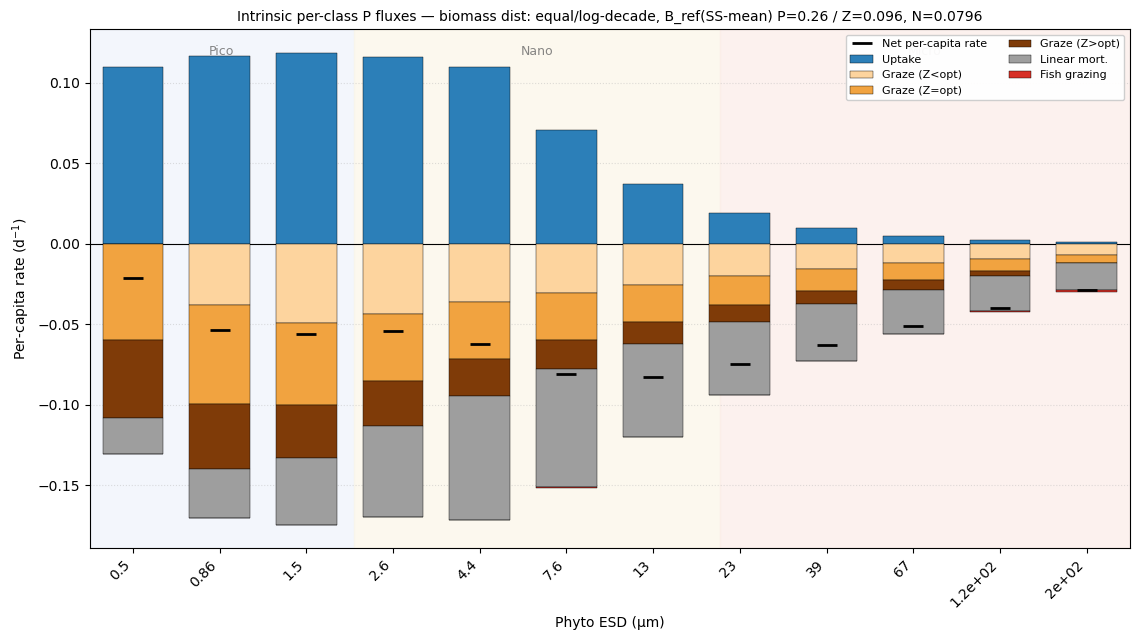

In [6]:
from flux_plot import plot_intrinsic_phyto_fluxes, plot_intrinsic_zoo_fluxes

ig, ax = plt.subplots(figsize=(11.5, 6.5))
plot_intrinsic_phyto_fluxes(out_ss, biomass_dist='equal', biomass_ref='ss_mean', ax=ax)
plt.tight_layout(); plt.show()

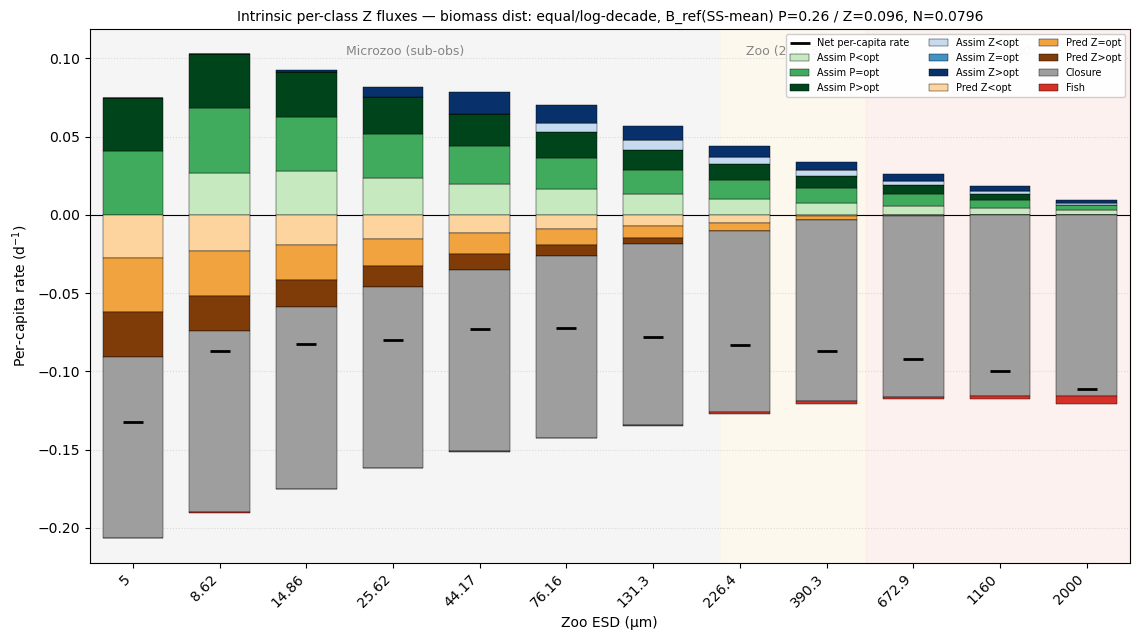

In [7]:
fig, ax = plt.subplots(figsize=(11.5, 6.5))
plot_intrinsic_zoo_fluxes(out_ss, biomass_dist='equal', biomass_ref='ss_mean', ax=ax)
plt.tight_layout(); plt.show()

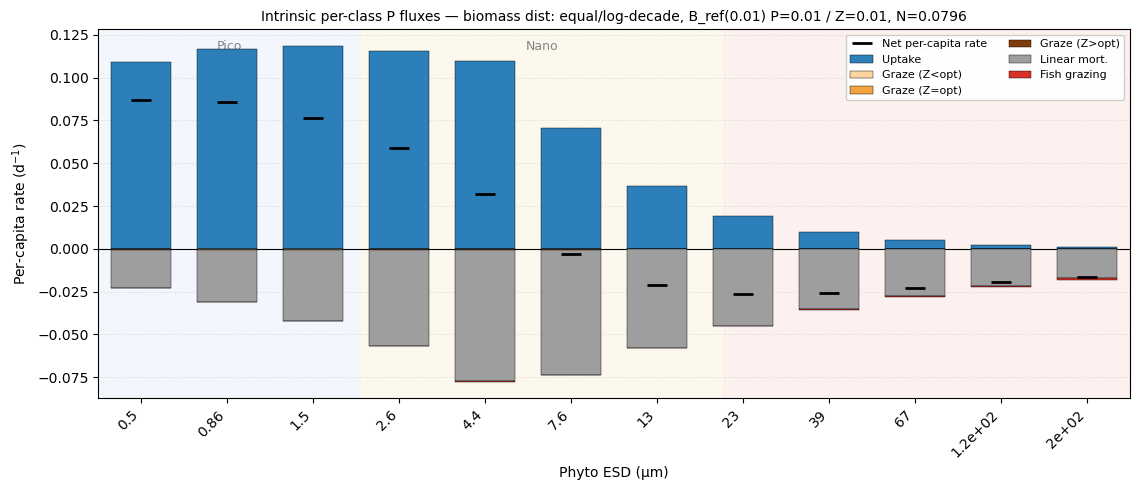

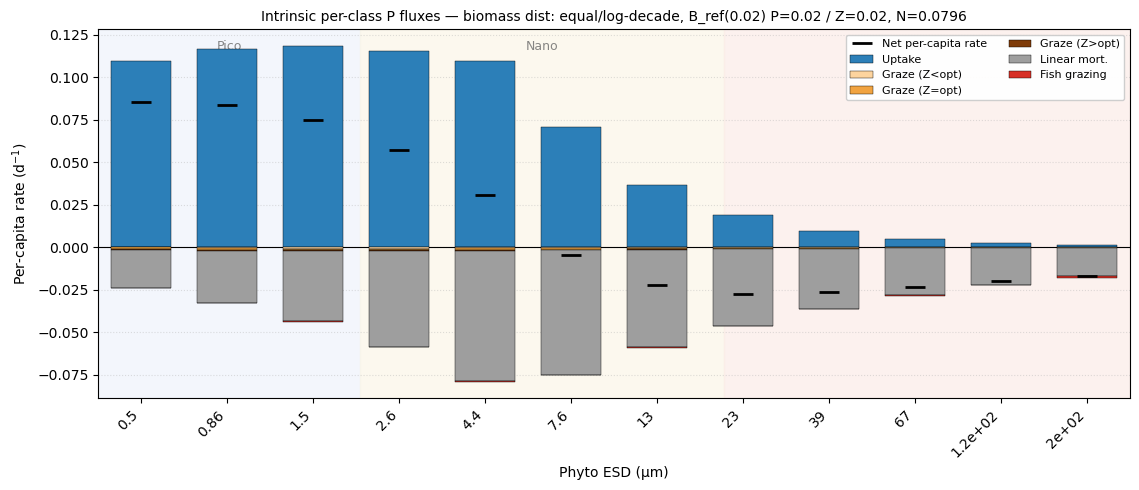

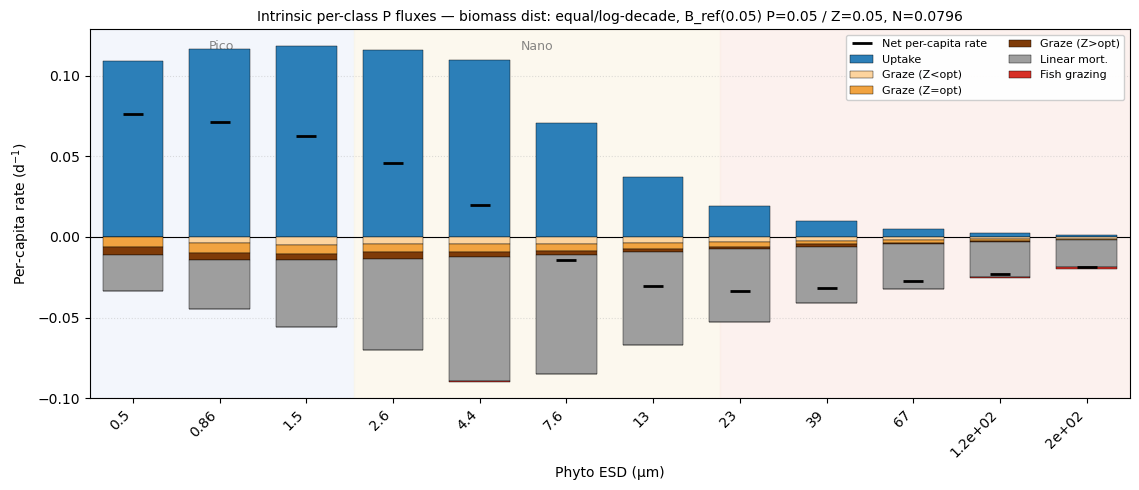

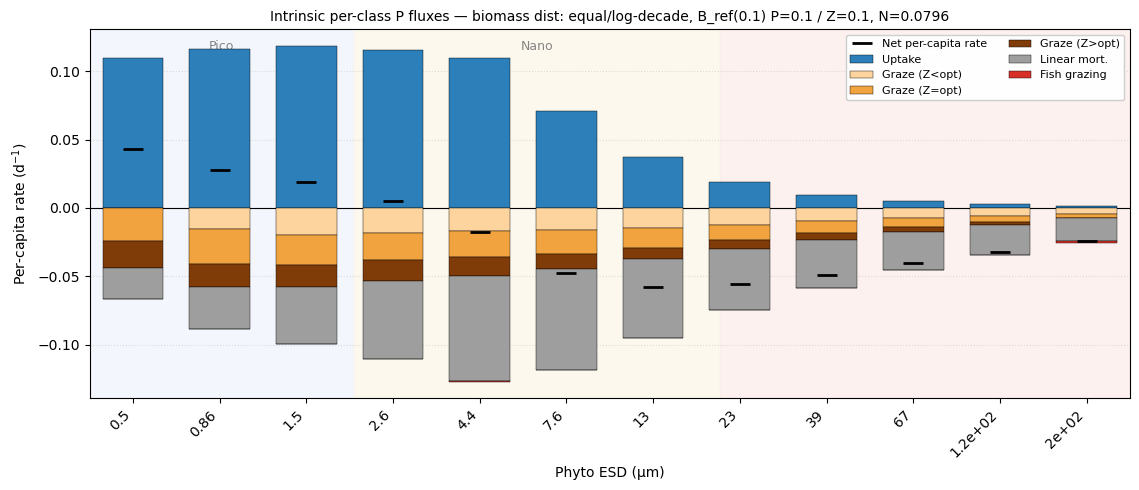

In [8]:
for B in [0.01, 0.02, 0.05, 0.1]:
    fig, ax = plt.subplots(figsize=(11.5, 5))
    plot_intrinsic_phyto_fluxes(out_ss, biomass_dist='equal', biomass_ref=B, ax=ax)
    plt.tight_layout(); plt.show()

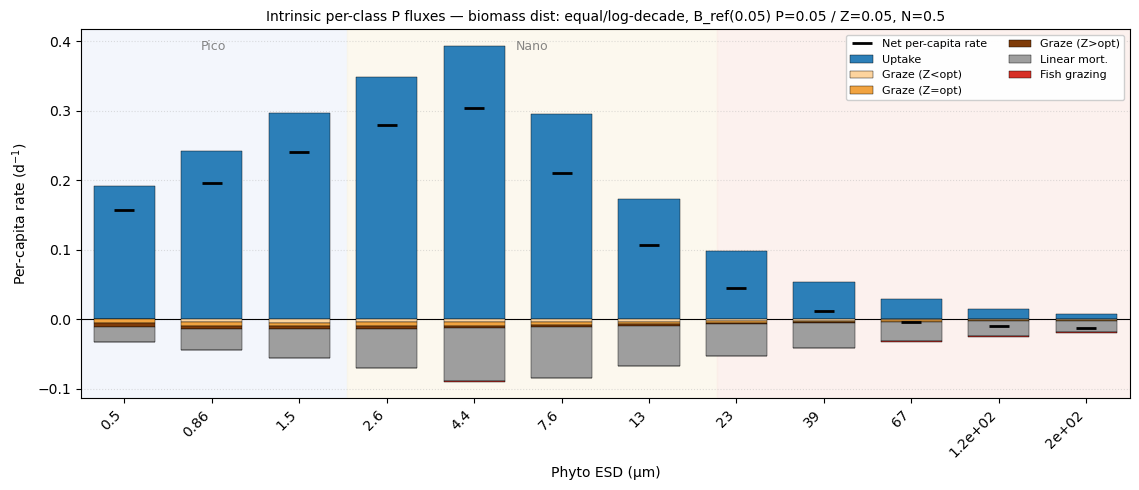

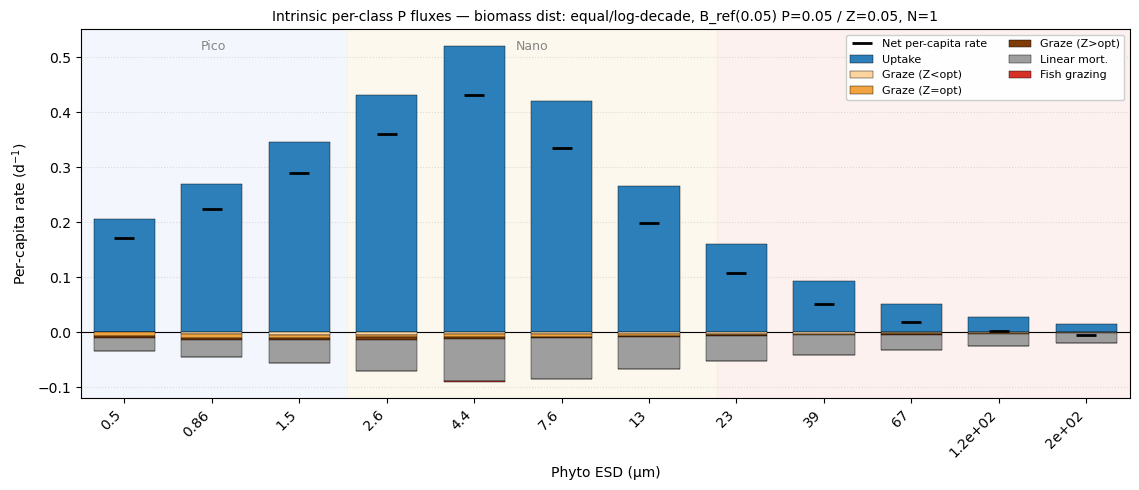

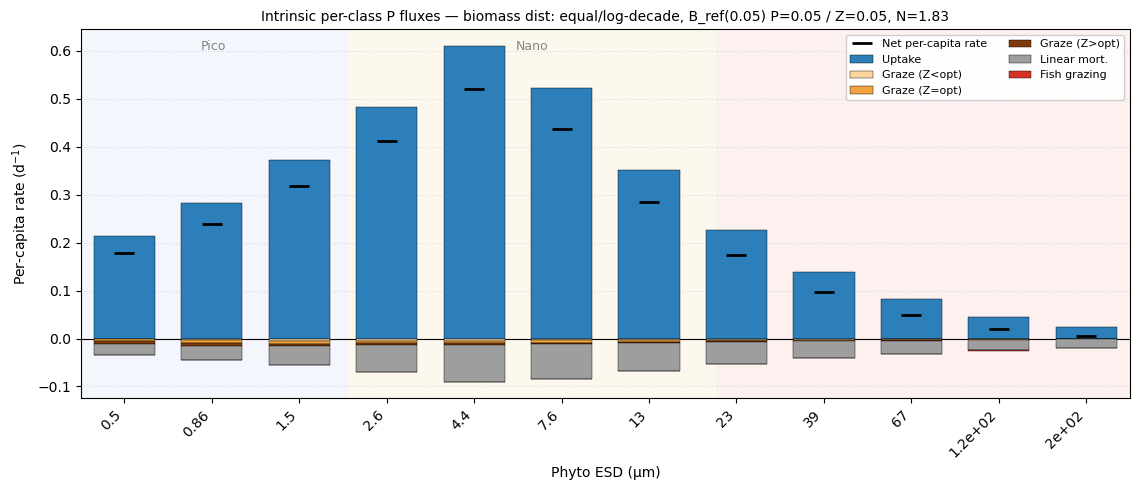

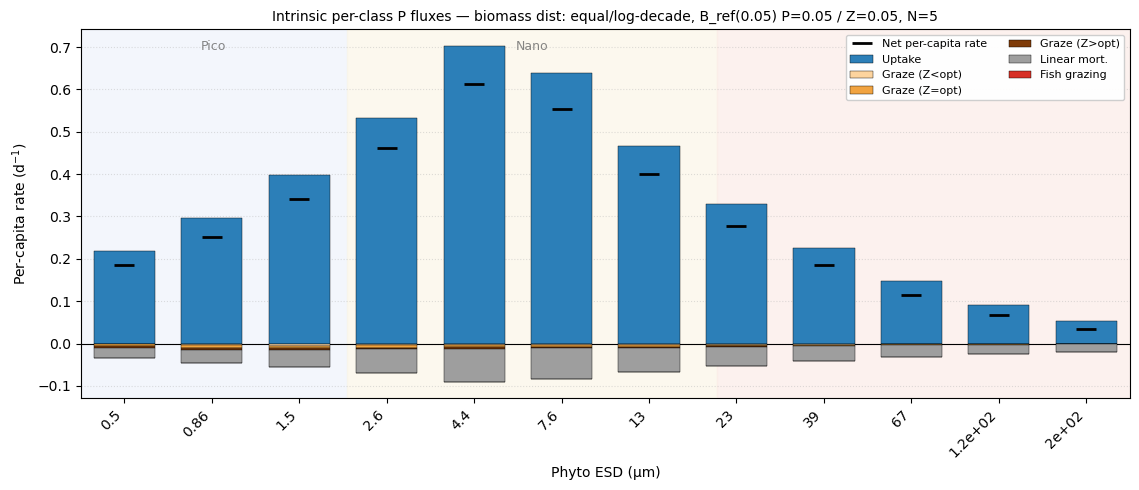

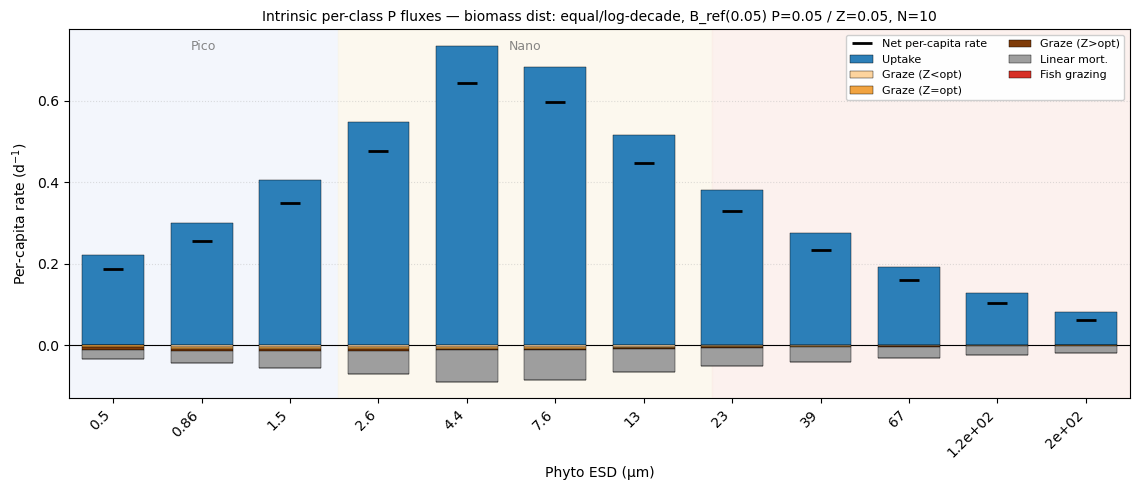

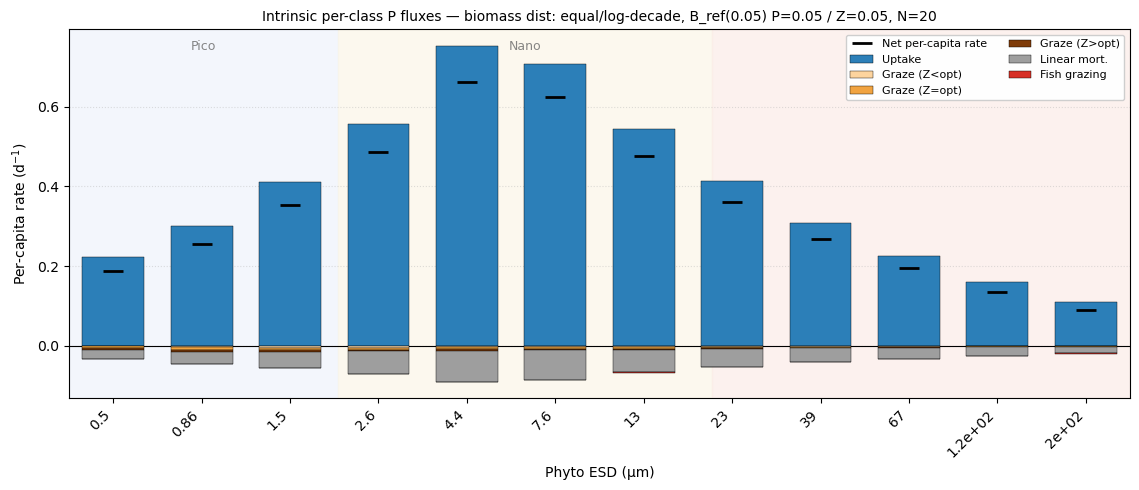

In [9]:
for N in [0.5, 1.0, 1.83, 5.0, 10.0, 20.0]:
    fig, ax = plt.subplots(figsize=(11.5, 5))
    plot_intrinsic_phyto_fluxes(out_ss, biomass_dist='equal',
                                 biomass_ref=0.05, N_ref=N, ax=ax)
    plt.tight_layout(); plt.show()